# Aggressive L+S+R Trading Strategy Test

This notebook sets up the data pipeline, trains the residual LSTM model, identifies a high-volatility sideways market window, and executes the **Aggressive L+S+R (Linear + Seasonal + Residual)** trading strategy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub

from sklearn.linear_model import LinearRegression
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

SEQ_LEN = 7200
HORIZON = 60
STEP = 20
MODEL_PATH = "LSTM_Residual_Model_Retrained.keras"

In [2]:
#data stuff
path = kagglehub.dataset_download("rockinbrock/spy-1-minute-data")
files = os.listdir(path)
csv_file = [f for f in files if f.lower().endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_file))

# last 100,000 rows rn
df = df.tail(100_000).reset_index(drop=True)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("Data loaded. Shape:", df.shape)
df.head()

100%|██████████| 22.1M/22.1M [00:00<00:00, 105MB/s] 

Extracting files...


Data loaded. Shape: (100000, 8)


,date,open,high,low,close,volume,barCount,average
0,2020-12-01 08:40:00,366.11,366.26,366.01,366.20,1560,902,366.194
1,2020-12-01 08:41:00,366.20,366.31,366.06,366.26,1276,803,366.210
2,2020-12-01 08:42:00,366.26,366.33,366.19,366.29,549,376,366.274
3,2020-12-01 08:43:00,366.30,366.41,366.27,366.39,765,492,366.354
4,2020-12-01 08:44:00,366.38,366.45,366.31,366.45,991,648,366.408


## 2. Model Training
We train the LSTM on the residuals (price - trend - seasonality) using the last 50,000 records as the training set.

In [3]:
# Use the last 50k rows for training
df_train = df.tail(50_000).reset_index(drop=True)
y_train_raw = df_train['close'].values
N_train = len(df_train)
t_train = np.arange(N_train)

# 1. Linear Trend Decomposition
trend_features = t_train.reshape(-1, 1)
trend_model = LinearRegression()
trend_model.fit(trend_features, y_train_raw)
L_train = trend_model.predict(trend_features)

# 2. Fourier Seasonality Decomposition
T_period = 1440 # Daily cycle in minutes
K = 5           # Number of harmonics

seasonal_basis = []
for k in range(1, K+1):
    seasonal_basis.append(np.sin(2*np.pi*k*t_train/T_period))
    seasonal_basis.append(np.cos(2*np.pi*k*t_train/T_period))
seasonal_basis = np.vstack(seasonal_basis).T

seasonal_model = LinearRegression()
seasonal_model.fit(seasonal_basis, y_train_raw - L_train)
S_train = seasonal_model.predict(seasonal_basis)

# 3. Residuals
R_train_raw = y_train_raw - L_train - S_train

# 4. Prepare Sliding Windows
features = ['open','high','low','close','volume','barCount','average']
X_all = df_train[features].values.astype(np.float32)

X_seq, R_seq = [], []

for i in range(0, N_train - SEQ_LEN - HORIZON, STEP):
    X_seq.append(X_all[i:i+SEQ_LEN])
    R_seq.append(R_train_raw[i+SEQ_LEN:i+SEQ_LEN+HORIZON])

X_seq = np.array(X_seq, dtype=np.float32)
R_seq = np.array(R_seq, dtype=np.float32)

print(f"Training sequences: {X_seq.shape}")

# 5. Train LSTM
split = int(0.8 * len(X_seq))
X_tr, X_val = X_seq[:split], X_seq[split:]
R_tr, R_val = R_seq[:split], R_seq[split:]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 7)),
    Dropout(0.2),
    LSTM(64),
    Dense(128, activation='relu'),
    Dense(HORIZON)
])

model.compile(optimizer=Adam(1e-3), loss='mse')
history = model.fit(
    X_tr, R_tr,
    validation_data=(X_val, R_val),
    epochs=2,
    batch_size=32,
    verbose=1
)

model.save(MODEL_PATH)
print("Model saved successfully.")

Training sequences: (2137, 7200, 7)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
54/54 ━━━━━━━━━━━━━━━━━━━━ 30s 476ms/step - loss: 31.7230 - val_loss: 76.8498
Epoch 2/2
54/54 ━━━━━━━━━━━━━━━━━━━━ 25s 460ms/step - loss: 17.5633 - val_loss: 90.9210
Model saved successfully.


## 3. Window Selection & Inference
We identify a specific 30-day window characterized by high volatility but sideways movement (low trend), which is ideal for this specific strategy.

In [5]:
# Load Model
model = load_model(MODEL_PATH)

# --- Find Sideways + Volatile Window ---
WINDOW_DAYS = 30
days = df['date'].dt.date.unique()
candidates = []

for i in range(len(days) - WINDOW_DAYS):
    d_start = days[i]
    d_end   = days[i + WINDOW_DAYS - 1]

    # Ensure strictly separate from training data
    if d_end >= df_train['date'].iloc[0].date():
        continue

    slice_df = df[(df['date'].dt.date >= d_start) &
                  (df['date'].dt.date <= d_end)]

    if len(slice_df) < 3000: continue

    prices_slice = slice_df['close'].values
    ret = (prices_slice[-1] - prices_slice[0]) / prices_slice[0]
    vol = prices_slice.std() / prices_slice.mean()

    # Maximizing Volatility / (Trend Strength + epsilon)
    score = vol / (abs(ret) + 1e-6)
    candidates.append((score, i, d_start, d_end))

# Select best window
best_score, idx, w_start, w_end = sorted(candidates, key=lambda x: -x[0])[0]
print(f"Selected Window: {w_start} to {w_end} (Score: {best_score:.2f})")

df_test = df[(df['date'].dt.date >= w_start) & (df['date'].dt.date <= w_end)].reset_index(drop=True)
y_test = df_test['close'].values
N_test = len(df_test)
t_test = np.arange(N_test)

# --- Inference: Re-calculate Trend/Seasonality for this window ---
# Note: In a live setting, we would project forward. For backtest, we fit L & S on the window to isolate Residuals.
trend_features_test = t_test.reshape(-1,1)
trend_model_test = LinearRegression()
trend_model_test.fit(trend_features_test, y_test)
L_test = trend_model_test.predict(trend_features_test)

seasonal_basis_test = []
for k in range(1, K+1):
    seasonal_basis_test.append(np.sin(2*np.pi*k*t_test/T_period))
    seasonal_basis_test.append(np.cos(2*np.pi*k*t_test/T_period))
seasonal_basis_test = np.vstack(seasonal_basis_test).T

seasonal_model_test = LinearRegression()
seasonal_model_test.fit(seasonal_basis_test, y_test - L_test)
S_test = seasonal_model_test.predict(seasonal_basis_test)

R_true_test = y_test - L_test - S_test

# --- Prepare Test Windows ---
X_all_test = df_test[features].values.astype(np.float32)
X_seq_test = []

for i in range(0, N_test - SEQ_LEN - HORIZON, STEP):
    X_seq_test.append(X_all_test[i:i+SEQ_LEN])

X_seq_test = np.array(X_seq_test, dtype=np.float32)

# --- Predict Residuals ---
R_pred_test = model.predict(X_seq_test, batch_size=32)

# --- Reconstruct Price Predictions ---
Y_pred_test, Y_true_test = [], []
for idx in range(len(X_seq_test)):
    start = idx * STEP + SEQ_LEN
    end = start + HORIZON

    Y_pred_test.append(L_test[start:end] + S_test[start:end] + R_pred_test[idx])
    Y_true_test.append(y_test[start:end])

Y_pred_test = np.array(Y_pred_test)
Y_true_test = np.array(Y_true_test)
print("Prediction Matrix Shape:", Y_pred_test.shape)

Selected Window: 2020-12-03 to 2021-01-15 (Score: 0.56)
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step
Prediction Matrix Shape: (1857, 60)


## 4. Aggressive Strategy Execution & Plotting
This section runs the final trading strategy utilizing small thresholds to trigger frequent trades, comparing the result against standard Buy & Hold.

Aggressive Strategy Final PnL: 17.33999999999969
Total Trades: 171 Flips: 45


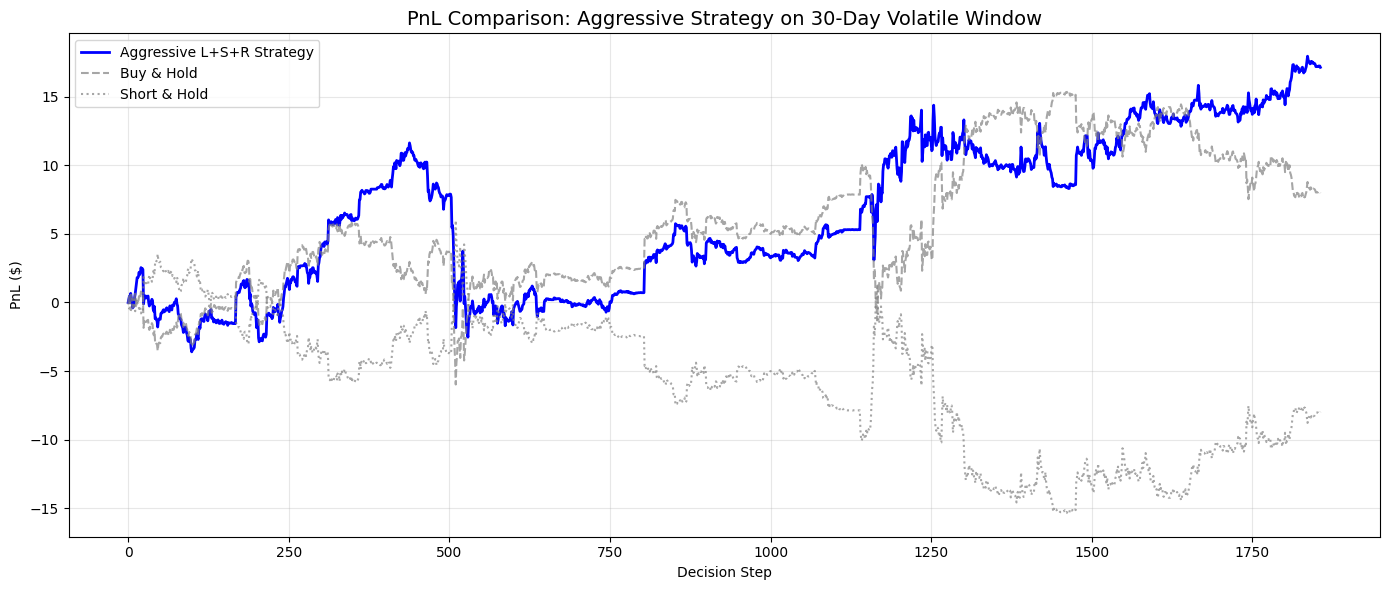

In [6]:
# --- Setup Comparisons ---
prices = df_test['close'].values
P_start = prices[SEQ_LEN]
bh_full = prices - P_start
sh_full = P_start - prices

# Align timestamps
anchor_times = [
    w * STEP + SEQ_LEN
    for w in range(Y_pred_test.shape[0])
    if w * STEP + SEQ_LEN < len(prices)
]
bh_curve = bh_full[anchor_times]
sh_curve = sh_full[anchor_times]

# --- End of Day Flattening ---
day_groups = df_test.groupby(df_test['date'].dt.date).apply(lambda g: g.index.to_numpy())
eod_flat_indices = set()
for _, idx_arr in day_groups.items():
    if len(idx_arr) >= 5: eod_flat_indices.update(idx_arr[-5:])
    else: eod_flat_indices.update(idx_arr)

# --- Strategy Parameters ---
T_ENTER = 0.0005
T_EXIT  = 0.0002
T_FLIP  = 0.0008

def current_equity(p0, position, entry_price, pnl_realized):
    if position == 0 or entry_price is None:
        return pnl_realized
    return pnl_realized + position * (p0 - entry_price)

position = 0
entry_price = None
pnl_realized = 0.0
equity_curve_aggr = []
num_trades = 0
num_flips = 0

# --- Trading Loop ---
for w in range(Y_pred_test.shape[0]):
    t0 = w * STEP + SEQ_LEN
    if t0 >= len(prices):
        break

    P0 = prices[t0]

    # Signal weights (short-term focus)
    P1  = Y_pred_test[w, 1]
    P10 = Y_pred_test[w, 10]
    P30 = Y_pred_test[w, 30]

    r1  = (P1 - P0) / P0
    r10 = (P10 - P0) / P0
    r30 = (P30 - P0) / P0

    signal = 0.6 * r1 + 0.3 * r10 + 0.1 * r30

    # Signal to Direction
    if signal > T_ENTER:
        desired = 1
    elif signal < -T_ENTER:
        desired = -1
    else:
        desired = 0

    if t0 in eod_flat_indices:
        desired = 0

    # State Machine
    if position == 0:
        if desired != 0:
            position = desired
            entry_price = P0
            num_trades += 1

    elif position == 1:
        if signal < -T_FLIP:
            pnl_realized += (P0 - entry_price)
            num_flips += 1; num_trades += 2
            position = -1
            entry_price = P0
        elif abs(signal) < T_EXIT or desired == 0:
            pnl_realized += (P0 - entry_price)
            position = 0
            entry_price = None
            num_trades += 1

    elif position == -1:
        if signal > T_FLIP:
            pnl_realized += (entry_price - P0)
            num_flips += 1; num_trades += 2
            position = 1
            entry_price = P0
        elif abs(signal) < T_EXIT or desired == 0:
            pnl_realized += (entry_price - P0)
            position = 0
            entry_price = None
            num_trades += 1

    eq = current_equity(P0, position, entry_price, pnl_realized)
    equity_curve_aggr.append(eq)

print("Aggressive Strategy Final PnL:", pnl_realized)
print("Total Trades:", num_trades, "Flips:", num_flips)

# --- Visualization ---
steps = np.arange(len(equity_curve_aggr))

plt.figure(figsize=(14,6))
plt.plot(steps, equity_curve_aggr, label="Aggressive L+S+R Strategy", linewidth=2, color='blue')
plt.plot(steps, bh_curve[:len(steps)], label="Buy & Hold", linestyle="--", color='gray', alpha=0.7)
plt.plot(steps, sh_curve[:len(steps)], label="Short & Hold", linestyle=":", color='gray', alpha=0.7)
plt.title("PnL Comparison: Aggressive Strategy on 30-Day Volatile Window", fontsize=14)
plt.xlabel("Decision Step")
plt.ylabel("PnL ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()